# Análise de resultados  - PAND

**Título Original do Projeto: PAND: Orquestração entre Visão Computacional e LLM para Tomada de Decisão na Manutenção Fotovoltaica**

**Autor: Matheus Naranjo Corrêa**

*Data: 05 de Março de 2026*

**Objetivo**: Analisar os dados gerados pelo projeto PAND para fins de TCC.

**Resumo**: A expansão solar dificulta a manutenção, com inspeções visuais isoladas frequentemente imprecisas. Este estudo valida a arquitetura PAND para reduzir falsos positivos via fusão de dados visuais (YOLOv11m) e telemétricos, orquestrada por um núcleo agêntico (Llama 3.3). Em 100 testes simulados com conflito visual-elétrico, obteve Taxa de Assertividade de 92,0% e eficácia de 100% em casos críticos, com o tempo de inferência variando conforme a ambiguidade do cenário (média de 19,6s) Demonstra a viabilidade da fusão semântica para automação industrial, sugerindo futuras pesquisas em modelos de borda.


🟨 Peço atenção quanto a este notebook: caso rode, faça no ambiente do colab

In [1]:
"""
- Matriz de Confusão: Com cores (Blues) e valores numéricos (annot=True).
- Demais gráficos: Padrão visual (sem números) e alto contraste.
- Proporção 7x10 (y:x) mantida em todos (figsize=(10, 7)).
"""

import pandas as pd
import json
import re
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# --- Configurações de Caminho ---
CSV_RESULTADO_PATH = "RESULTADO_FINAL_TCC.csv"
JSON_MAPA_PATH = "mapa_cenarios.json"
PASTA_SAIDA = "data/figuras"

def extrair_codigo(texto):
    match = re.search(r'\[CÓDIGO:\s*([^\]]+)\]', str(texto))
    return match.group(1).strip() if match else "ERRO_FORMATACAO"

def carregar_dados_corrigidos(csv_resultado: str, json_mapa: str) -> pd.DataFrame:
    with open(json_mapa, "r", encoding="utf-8") as f:
        mapa = json.load(f)
    df = pd.read_csv(csv_resultado, on_bad_lines="skip")
    col_resultado = "Resultado_A3" if "Resultado_A3" in df.columns else "Relatorio_Completo"
    df["Decisao_PAND"] = df[col_resultado].apply(extrair_codigo)
    df["Cenario_Correto"] = df["Painel"].map(mapa)
    df["Esperado"] = df["Cenario_Correto"].map({
        "A (Convergência Ruim)": "LIMPEZA_CORRETIVA",
        "B (Falso Positivo)": "FALSO_POSITIVO_IGNORADO",
        "C (Falha Oculta)": "MANUTENCAO_ELETRICA",
        "D (Controle)": "OPERACAO_NORMAL",
        "E (Ambiguidade Extrema)": "INSPECAO_AMBIGUIDADE",
    })
    df["Acerto"] = df["Decisao_PAND"] == df["Esperado"]
    if "Tempo_s" not in df.columns:
        df["Tempo_s"] = np.nan
    return df

def gerar_figura_confusao(df: pd.DataFrame, output_path: str):
    """
    EXCEÇÃO: Matriz de confusão com cores e números.
    """
    ordem = ["LIMPEZA_CORRETIVA", "FALSO_POSITIVO_IGNORADO", "MANUTENCAO_ELETRICA", "OPERACAO_NORMAL", "INSPECAO_AMBIGUIDADE"]
    esperados = [c for c in ordem if c in df["Esperado"].values]
    decisoes = [c for c in ordem if c in df["Decisao_PAND"].values]

    matriz = pd.crosstab(df["Esperado"], df["Decisao_PAND"]).reindex(index=esperados, columns=decisoes, fill_value=0)

    # Proporção 7x10 (Largura 10, Altura 7)
    fig, ax = plt.subplots(figsize=(10, 7))

    # annot=True exibe os números; cmap="Blues" traz a cor de volta
    # Adicionado annot_kws para aumentar os números dentro da matriz
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", linewidths=1, linecolor="white", cbar=True, ax=ax, annot_kws={"size": 12})

    ax.set_title("Matriz de Confusão — Decisões vs Necessidade Operacional", fontsize=16, fontweight="bold", pad=20)

    # Aumentado o tamanho da fonte dos rótulos (Eixos X e Y)
    ax.set_xlabel("Diagnóstico Gerado pelo Agente PAND", fontsize=14, fontweight="bold", labelpad=15)
    ax.set_ylabel("Cenário Operacional (Gabarito)", fontsize=14, fontweight="bold", labelpad=15)

    # Aumentado o tamanho da fonte das categorias (Ticks)
    plt.xticks(rotation=30, ha="right", fontsize=12)
    plt.yticks(rotation=0, fontsize=12)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()

def gerar_figura_tad(df: pd.DataFrame, output_path: str):
    """Gráfico de barras seguindo a regra geral (sem números, alto contraste)."""
    fig, ax = plt.subplots(figsize=(10, 7))
    cenarios = sorted(df["Cenario_Correto"].dropna().unique())
    tads = [df[df["Cenario_Correto"] == c]["Acerto"].mean() * 100 for c in cenarios]

    ax.bar(cenarios, tads, color="#444444", width=0.6, edgecolor="black")

    tad_global = df["Acerto"].mean() * 100
    ax.axhline(y=tad_global, color="black", linestyle="--", label=f"Média Global: {tad_global:.2f}%")

    ax.set_ylim(0, 105)

    # Aumentado o tamanho da fonte
    ax.set_ylabel("Taxa de Assertividade Decisória (%)", fontsize=14, fontweight="bold", labelpad=15)
    ax.set_title("Eficácia Decisória por Cenário", fontsize=16, fontweight="bold", pad=20)

    plt.xticks(rotation=15, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    ax.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()

def gerar_figura_tempo(df: pd.DataFrame, output_path: str):
    """Boxplot seguindo a regra geral (sem números, alto contraste)."""
    df_valid = df.dropna(subset=["Tempo_s", "Cenario_Correto"])
    if df_valid.empty: return
    cenarios = sorted(df_valid["Cenario_Correto"].unique())
    dados_tempo = [df_valid[df_valid["Cenario_Correto"] == c]["Tempo_s"].values for c in cenarios]

    fig, ax = plt.subplots(figsize=(10, 7))
    bp = ax.boxplot(dados_tempo, labels=cenarios, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#DDDDDD")

    # Aumentado o tamanho da fonte
    ax.set_ylabel("Tempo de Processamento (s)", fontsize=14, fontweight="bold", labelpad=15)
    ax.set_title("Distribuição do Tempo de Resposta por cenário", fontsize=16, fontweight="bold", pad=20)

    plt.xticks(rotation=15, ha="right", fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()

def run_analysis(csv_resultado_path: str, json_mapa_path: str, output_dir: str):
    os.makedirs(output_dir, exist_ok=True)
    df = carregar_dados_corrigidos(csv_resultado_path, json_mapa_path)

    # Gera a matriz colorida e numerada
    gerar_figura_confusao(df, os.path.join(output_dir, "figura_matriz_confusao.png"))

    # Gera os outros seguindo a regra rígida
    gerar_figura_tad(df, os.path.join(output_dir, "figura_TAD_por_cenario.png"))
    gerar_figura_tempo(df, os.path.join(output_dir, "figura_tempo_resposta.png"))

    # Exporta CSV para suas Tabelas (onde os números são permitidos pelo manual)
    df.groupby("Cenario_Correto")["Acerto"].mean().to_csv(os.path.join(output_dir, "DADOS_PARA_TABELAS.csv"))
    print(f"✅ Figuras geradas em {output_dir}")

run_analysis(CSV_RESULTADO_PATH, JSON_MAPA_PATH, PASTA_SAIDA)

/tmp/ipykernel_150/3993511957.py:109: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados_tempo, labels=cenarios, patch_artist=True)


✅ Figuras geradas em data/figuras


Exibindo gráficos da pasta: data/figuras

--- Tad Por Cenario ---


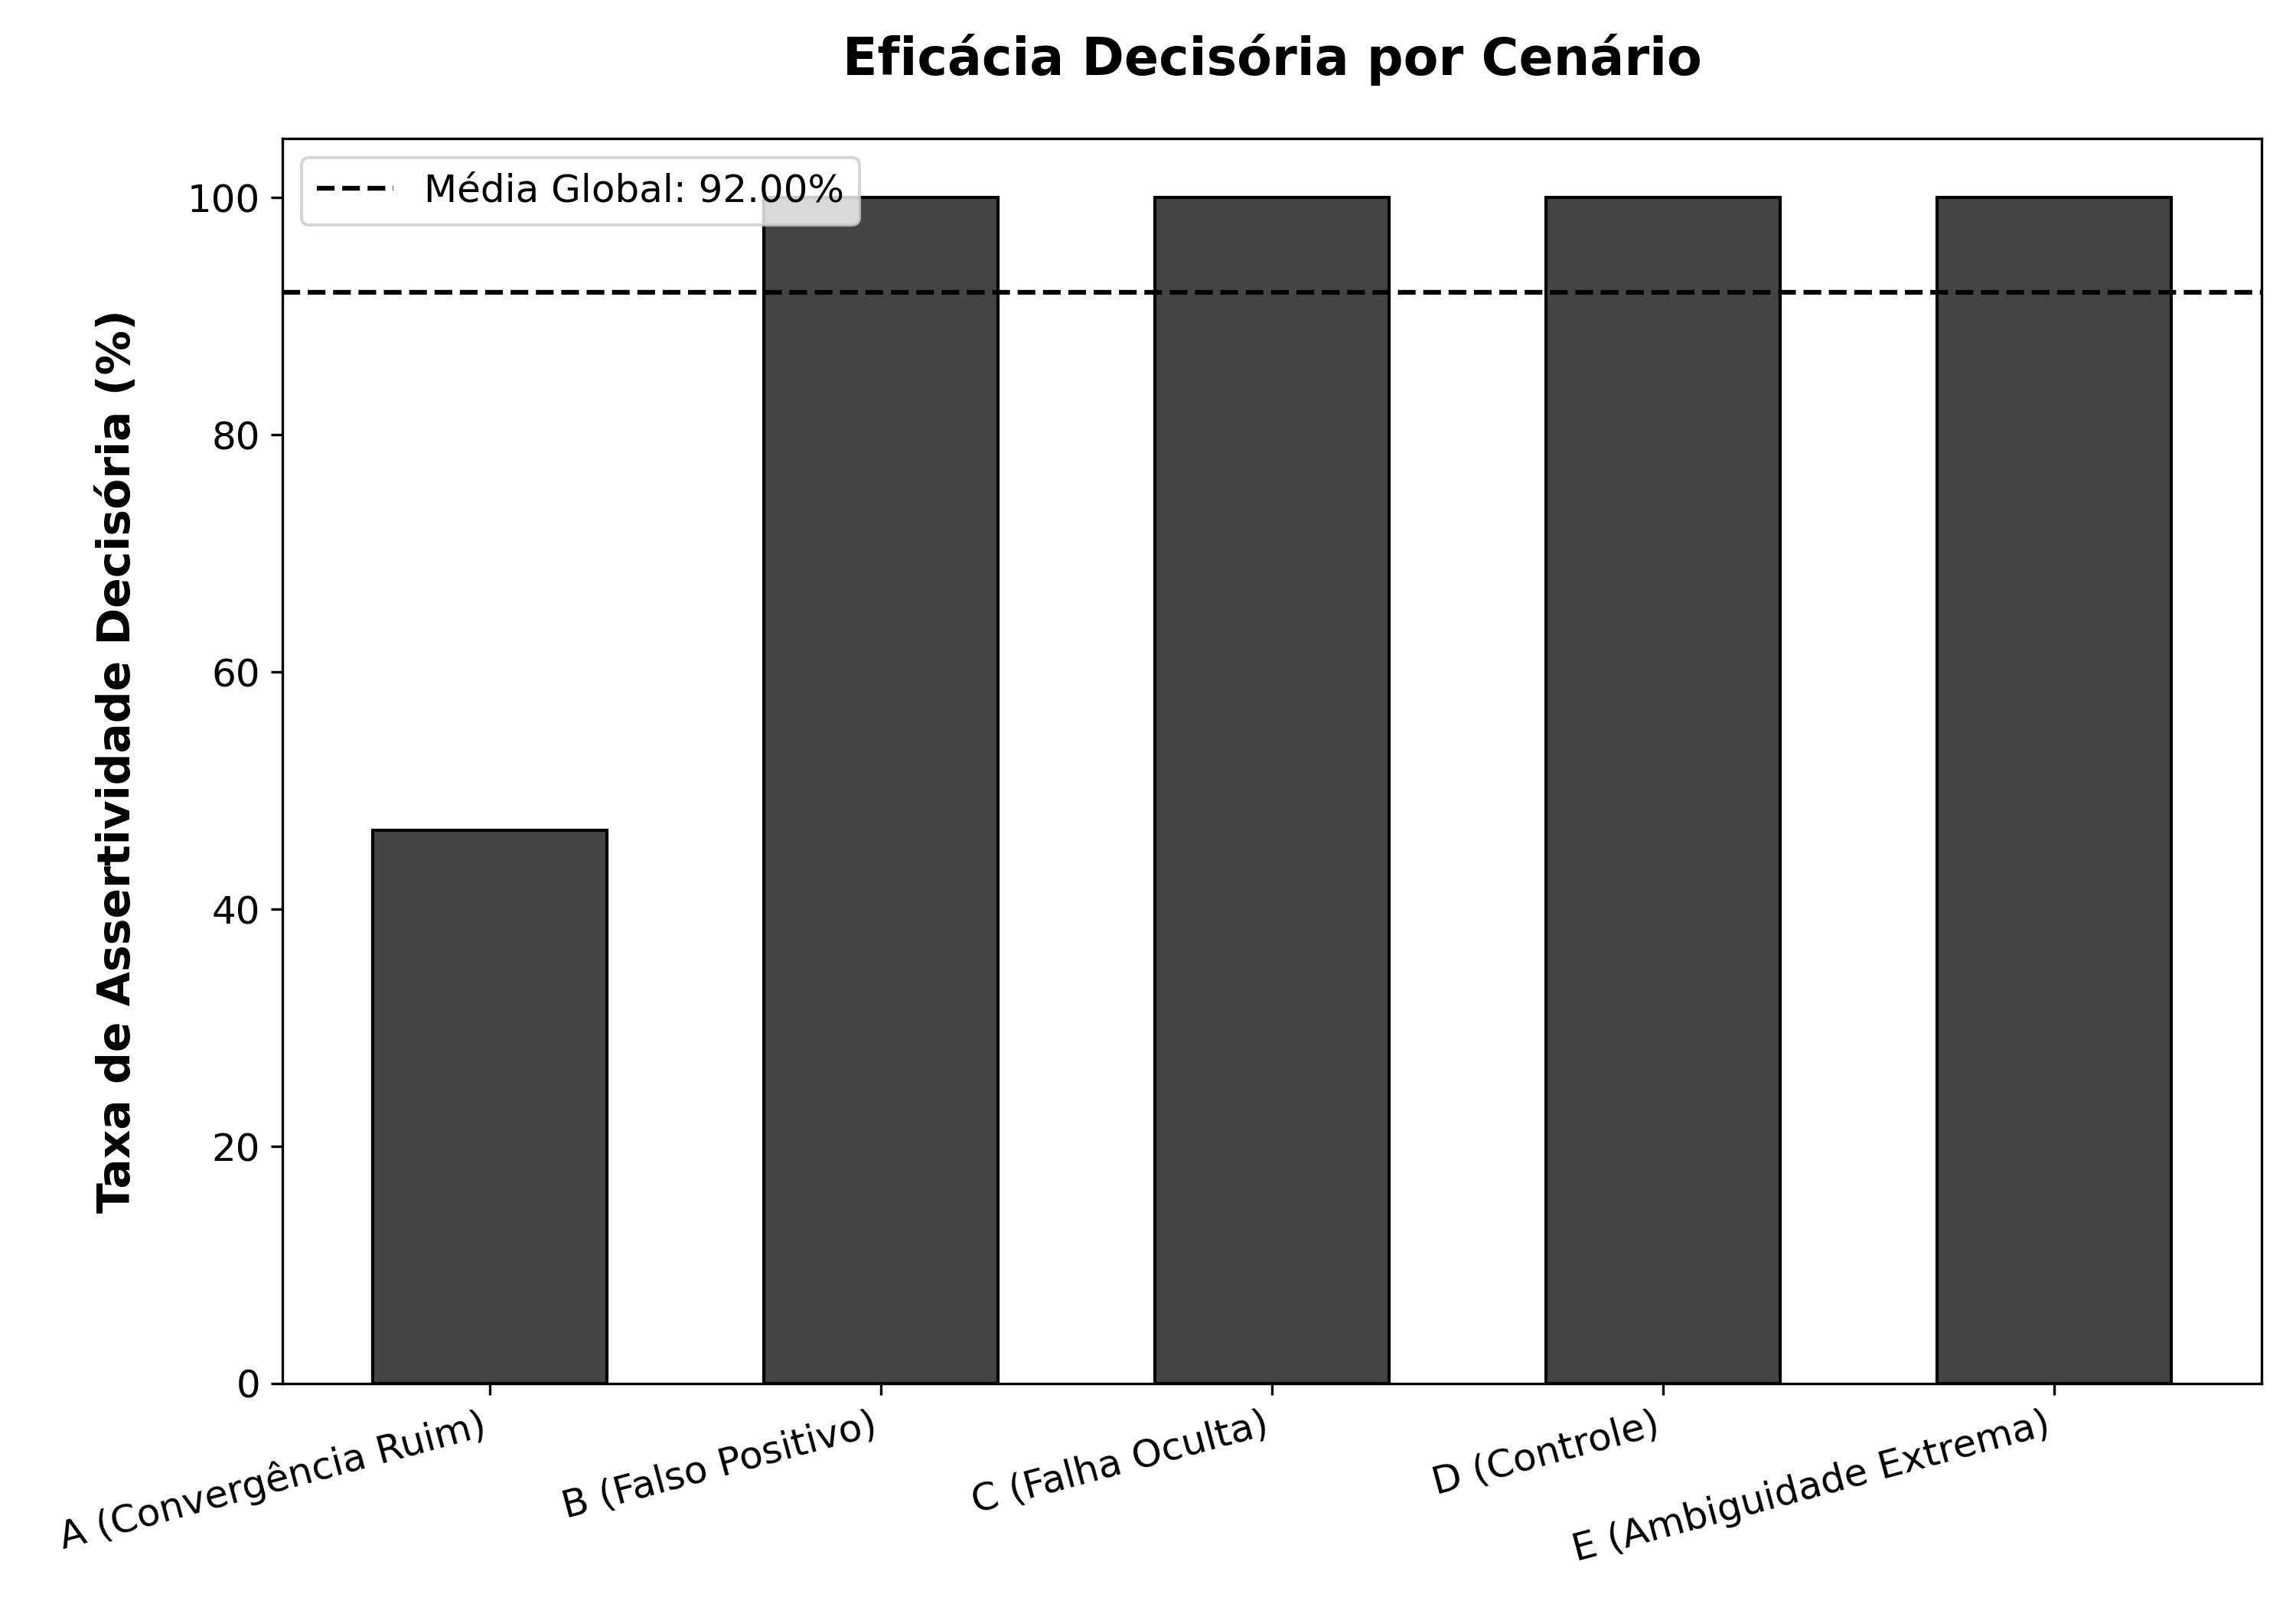


--- Matriz Confusao ---


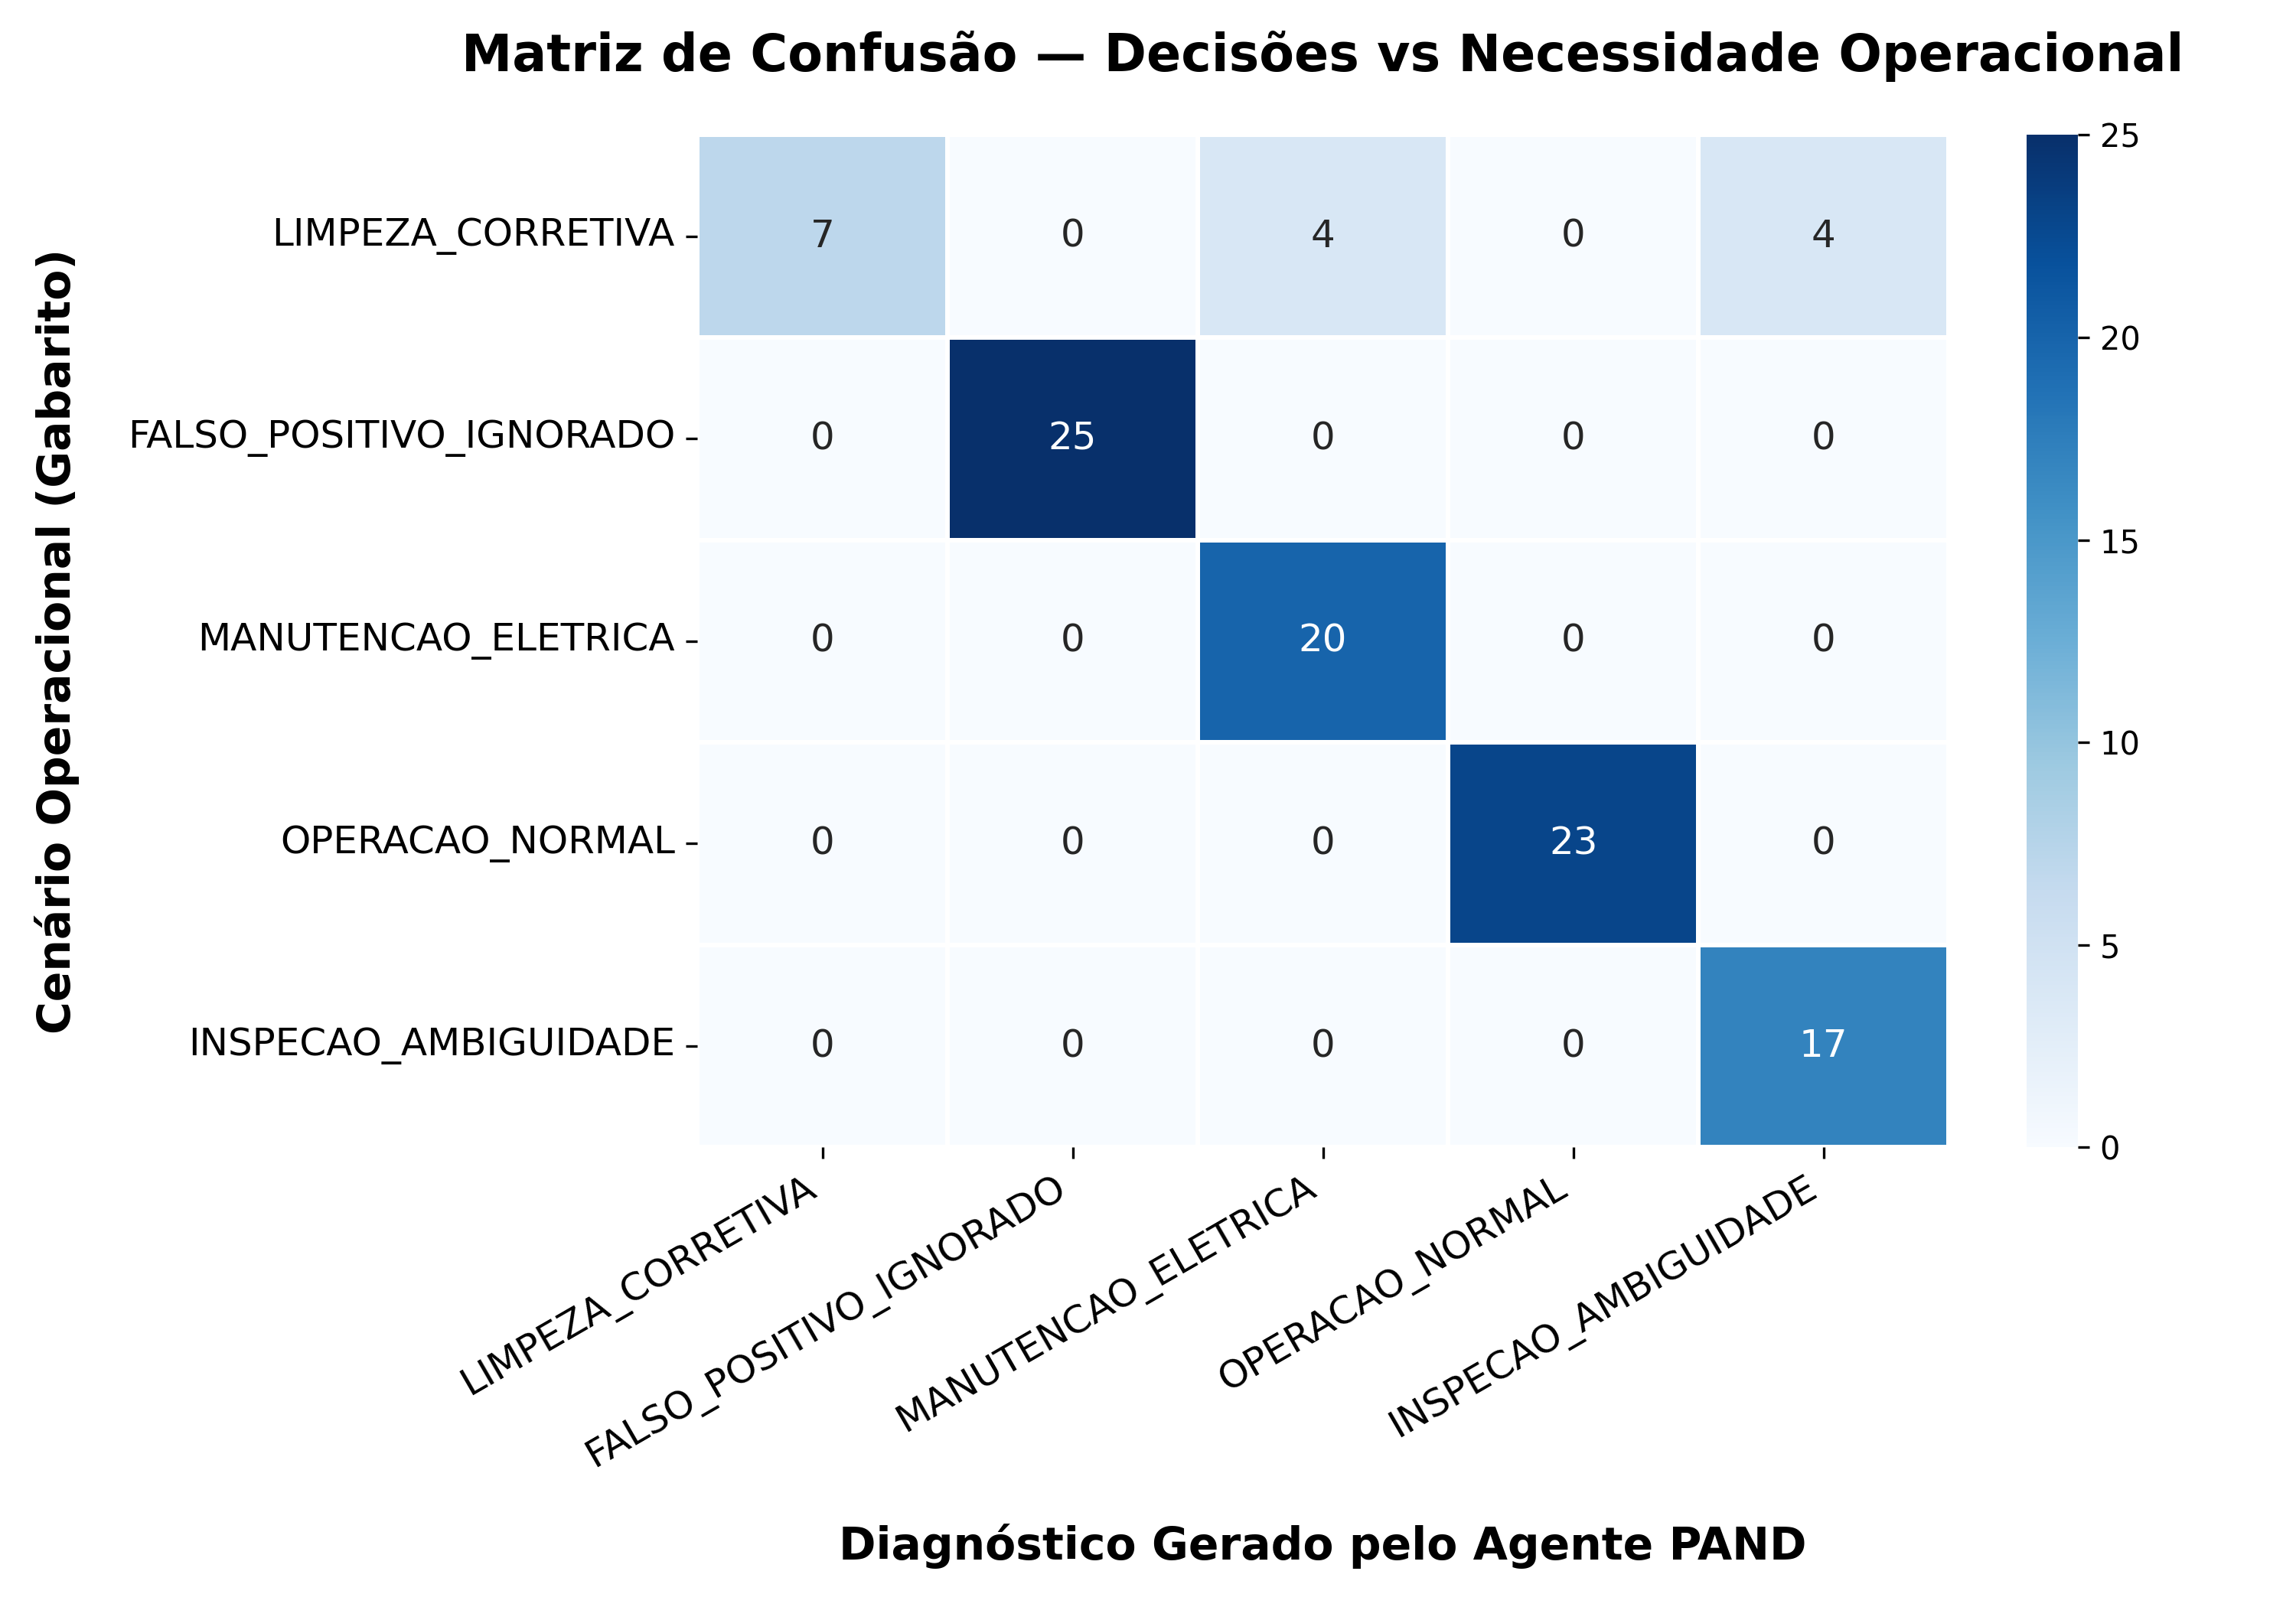


--- Tempo Resposta ---


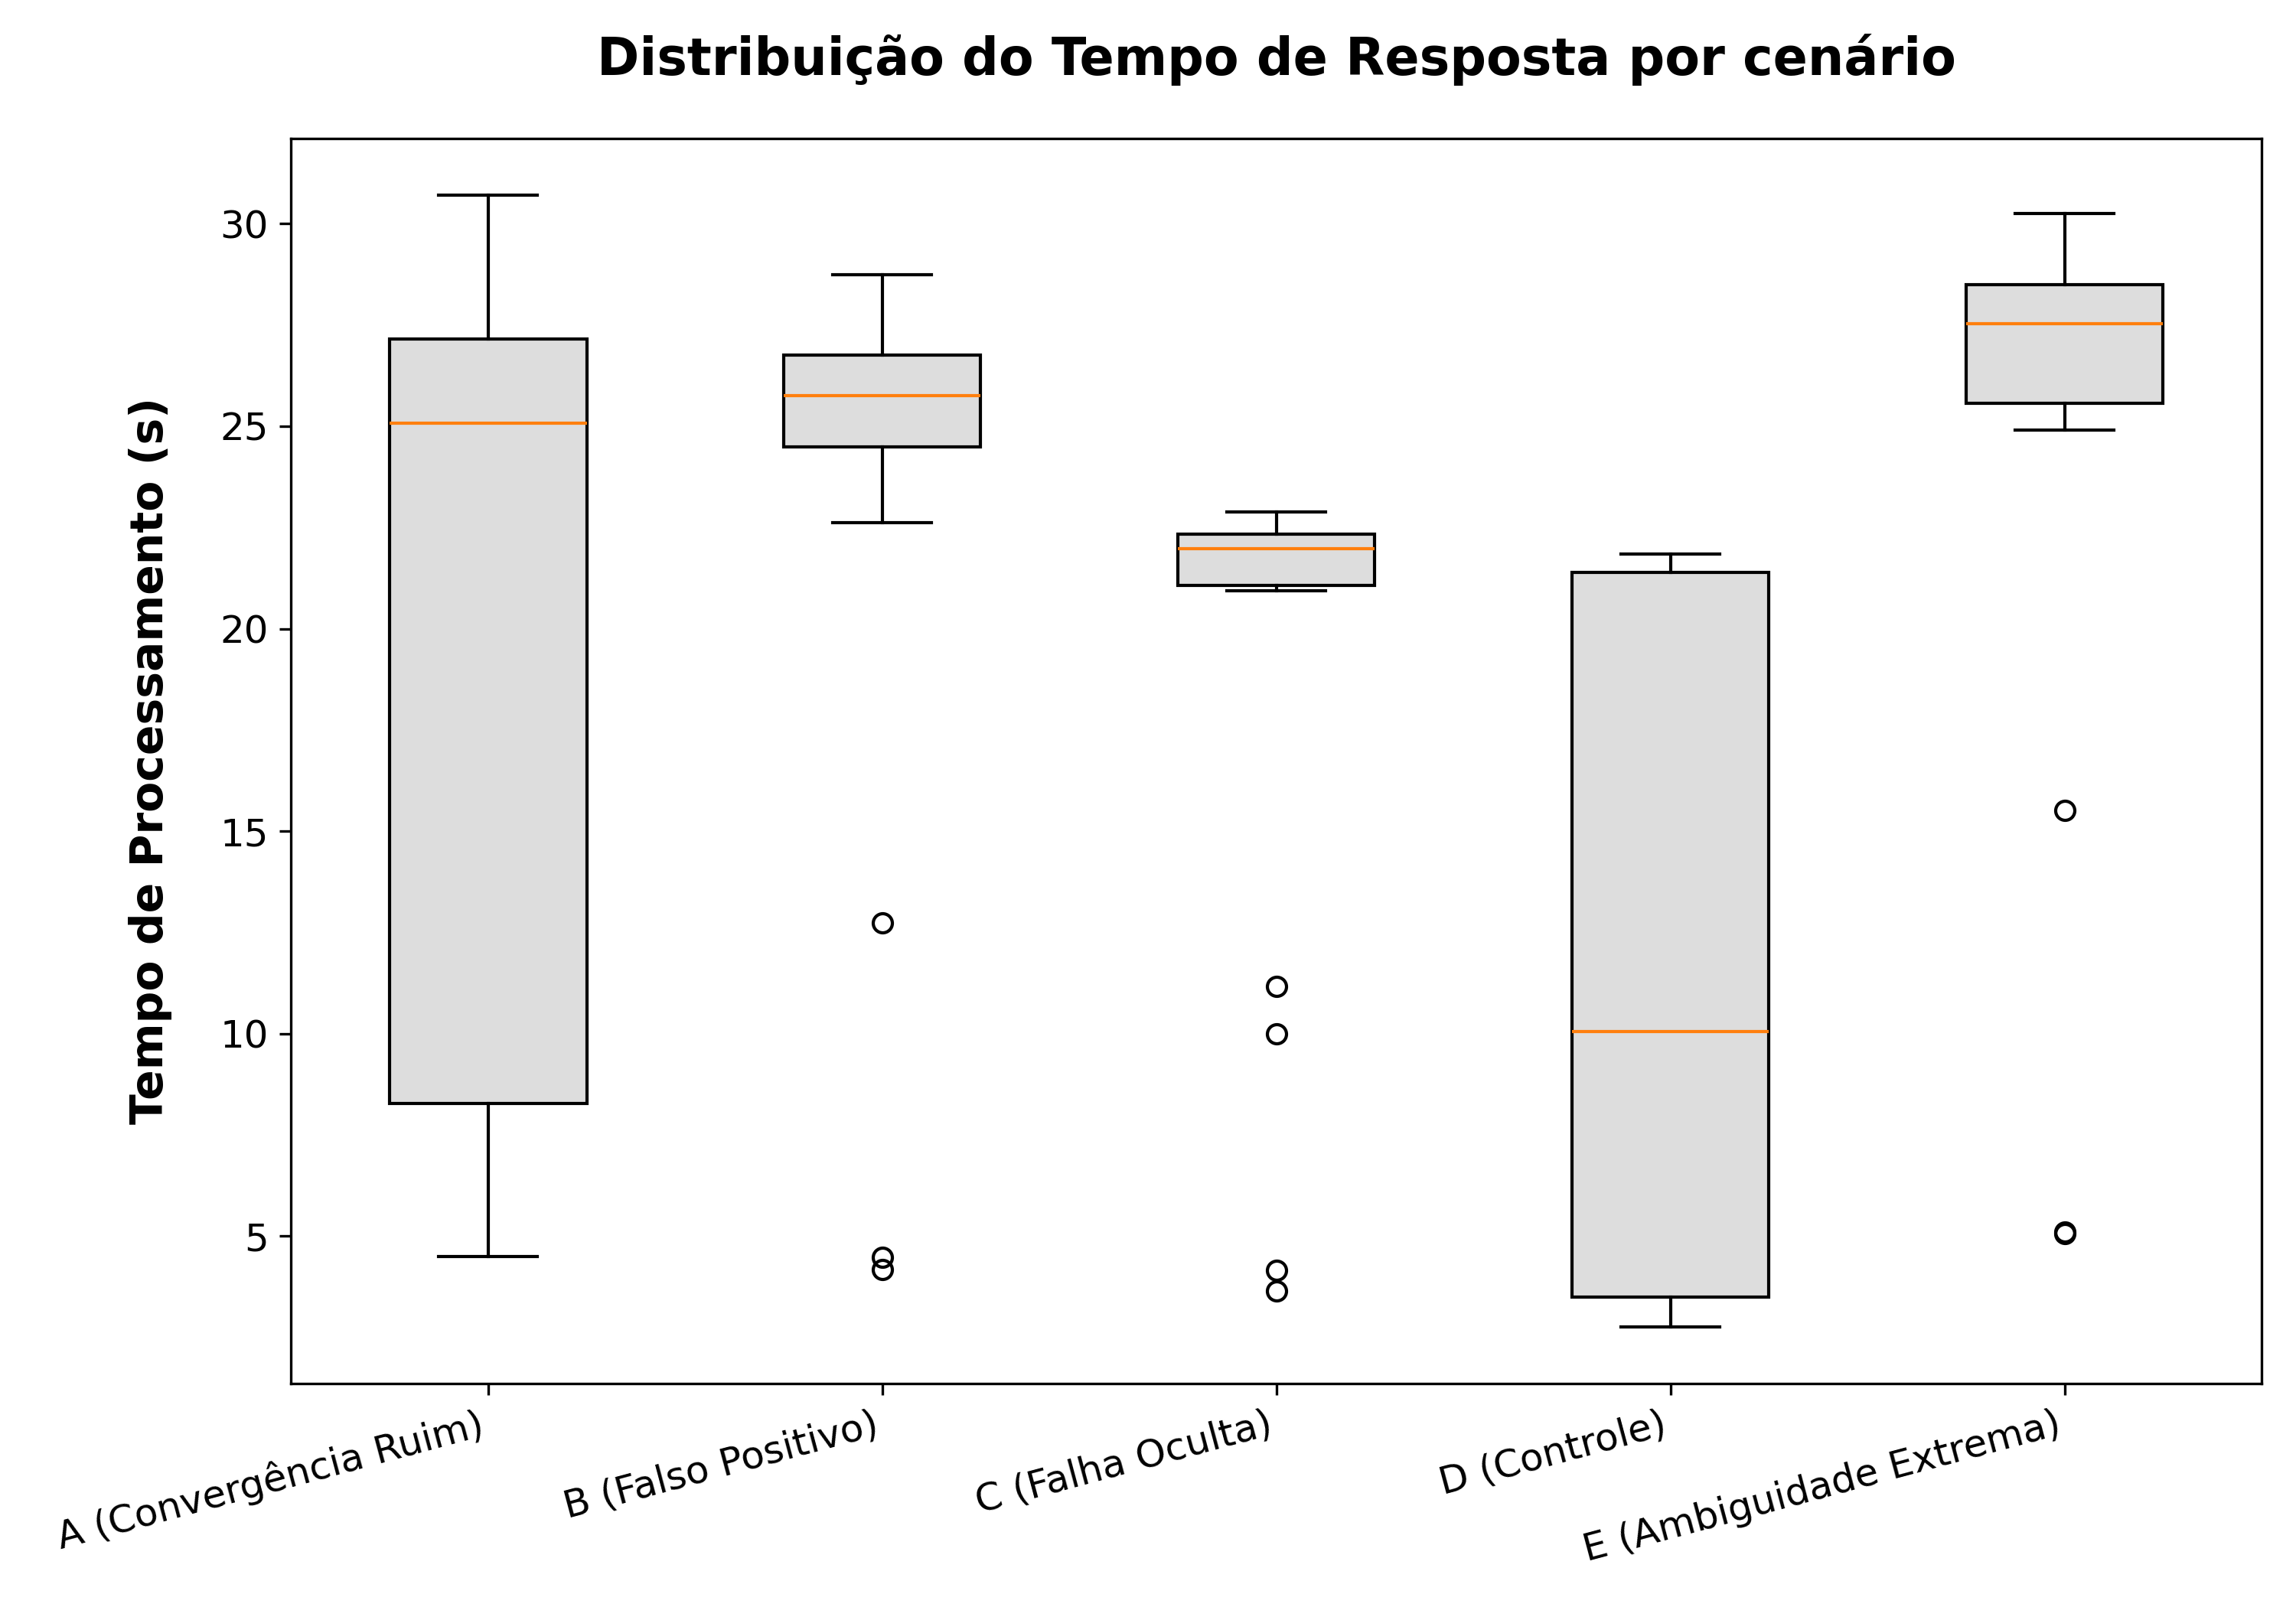

In [2]:
from IPython.display import Image, display
import os

# Certifique-se de que PASTA_SAIDA esteja definida no escopo global ou recupere o valor.
# Se não estiver definido, use o valor padrão 'data/figuras'
output_dir = globals().get('PASTA_SAIDA', 'data/figuras')

print(f"Exibindo gráficos da pasta: {output_dir}")

image_files = [
    os.path.join(output_dir, "figura_TAD_por_cenario.png"),
    os.path.join(output_dir, "figura_matriz_confusao.png"),
    os.path.join(output_dir, "figura_tempo_resposta.png"),
]

for img_path in image_files:
    if os.path.exists(img_path):
        print(f"\n--- {os.path.basename(img_path).replace('figura_', '').replace('.png', '').replace('_', ' ').title()} ---")
        display(Image(filename=img_path))
    else:
        print(f"⚠️ Aviso: O arquivo '{img_path}' não foi encontrado.")